# Imports and setup

In [1]:
# Imports
import os
from pathlib import Path
from urllib.parse import urlparse

from fastai.vision.all import *
from fastai.vision.gan import *
from fastai.vision.core import *

from ipywidgets import IntProgress
from IPython.display import display

# imports from other notebooks
from ipynb.fs.full.Deink_00_Utils import *
from ipynb.fs.full.Deink_00_Utils import _get_sil_y 

Image Size: (640, 480)


In [2]:
device = get_torch_device()

Total memory: 12884901888
Free memory: 3682140160
Used memory: 9202761728
CUDA is available: True


# Model Loading

In [3]:
# Load the model
%store -r
try:
    # See if the model file name is present from a prior notebook run
    model_file = deinked_gen_model_file 
except  NameError:
    model_file = './deinked-xresnet34_deeper-epocs250.pkl'
    
print(f"Using model: {model_file}")
learn = load_learner(model_file, cpu=not torch.cuda.is_available())

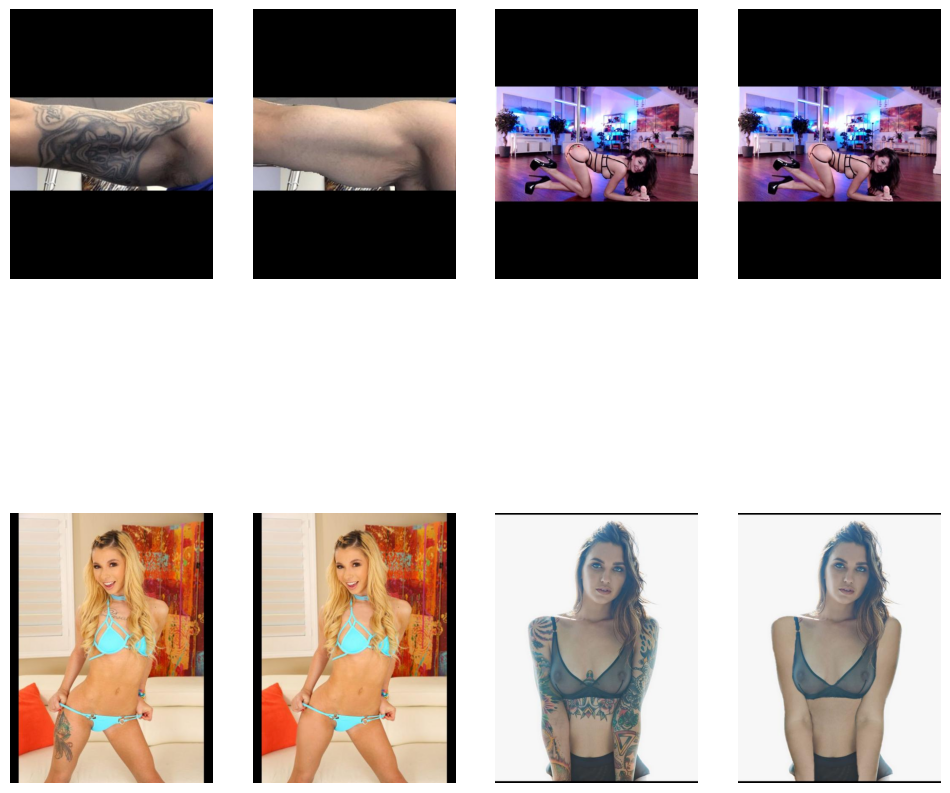

In [4]:
# Load our images
dls_gen = get_dls(batch_size, image_size) 
dls_gen.show_batch(max_n=4, figsize=(12,12))

In [5]:
# We'll want to get rid of any augmentation, drop_last, and shuffle from our training DataLoader:
dl = dls_gen.train.new(shuffle=False, drop_last=False, 
                       after_batch=[IntToFloatTensor, Normalize.from_stats(*imagenet_stats)])

In [6]:
# Get the predictions
preds, _ = learn_gen.get_preds(dl=dl)

# Save the predictions

In [7]:
#create the directory if needed
path_deinked_gen.mkdir(exist_ok=True)

# Clean things up in case there was already stuff there
for f in path_deinked_gen.glob('*.jpg'):
    os.remove(f)

In [8]:
# get the names of the dataset items
names = dl.dataset.items

max_count = len(names)
f = IntProgress(min=0, max=max_count, description="Predictions: ") # instantiate the bar
display(f) # display the bar

# loop over and save everything
for i,pred in enumerate(preds):
    f.value += 1 # signal to increment the progress bar
    
    #print(f'Saving {names[i].name}')
    dec = dl.after_batch.decode((TensorImage(pred[None]),))[0][0]
    arr = dec.numpy().transpose(1,2,0).astype(np.uint8)
    Image.fromarray(arr).save(path_deinked_gen/names[i].name)

172
Saving retouchme-40.jpeg
Saving retouchme-51.jpeg
Saving laser-removal-13.jpeg
Saving retouchme-78.jpeg
Saving retouchme-13.jpeg
Saving 101000555image (5).jpg
Saving training-28.jpeg
Saving training-99.png
Saving retouchme-3.jpeg
Saving retouchme-43.jpeg
Saving training-87.jpeg
Saving training-17.jpeg
Saving retouchme-9.jpeg
Saving retouchme-27.jpeg
Saving training-79.jpeg
Saving retouchme-67.jpeg
Saving training-56.jpeg
Saving laser-removal-1.jpeg
Saving retouchme-44.jpeg
Saving laser-removal-15.jpeg
Saving training-64.jpeg
Saving retouchme-58.jpeg
Saving retouchme-56.jpeg
Saving retouchme-41.jpeg
Saving laser-removal-4.jpeg
Saving training-9.jpeg
Saving retouchme-25.jpeg
Saving training-43.jpeg
Saving training-4.jpeg
Saving training-72.jpeg
Saving retouchme-24.jpeg
Saving training-50.jpeg
Saving retouchme-86.jpeg
Saving retouchme-31.jpeg
Saving training-51.jpeg
Saving retouchme-71.jpeg
Saving training-115.png
Saving 101000555image (18).jpg
Saving training-25.jpeg
Saving retouchme